<a href="https://colab.research.google.com/github/hyanghyanging/Beng_project/blob/main/DeeplabV3_800_epoch30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

구글 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!pip install torchmetrics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.2/840.2 kB 4.7 MB/s eta 0:00:00


In [ ]:
import os
import time
import glob
import torch
import torchmetrics
import torch.nn as nn
from glob import glob
from PIL import Image
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from sklearn.model_selection import train_test_split
from torchvision.transforms.functional import to_pil_image

데이터 불러오기

In [ ]:
IMAGE_SIZE = 512
BATCH_SIZE = 4     # 배치 사이즈 조정
NUM_CLASSES = 8    # 클래스 개수

In [ ]:
DATA_DIR = "/content/gdrive/MyDrive/위성데이터/Data/Training"
images = sorted(glob(os.path.join(DATA_DIR, 'Image/*')))
masks = sorted(glob(os.path.join(DATA_DIR, 'Labeling/*')))

# train, validation 분리
train_images, val_images, train_masks, val_masks = train_test_split(images, masks, train_size=80, test_size=20, random_state=42)  # 전체 데이터의 80%는 훈련. 20%는 검증

# Transformation 정의
transform = ToTensor()

In [ ]:
# 전체 데이터 크기
print(len(images))

800


In [ ]:
# 커스텀 데이터셋 : 데이터를 한 번에 다 부르지 않고 조금씩 나누어서 호출하는 방식. 한 번에 메모리에 불러오면 시간과 비용 측면에서 비효율적이기 때문
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")  # "L" mode for grayscale

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask


# CustomDataset 생성
train_dataset = CustomDataset(train_images, train_masks, transform=transform)
val_dataset = CustomDataset(val_images, val_masks, transform=transform)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


# DeepLabV3 model 정의
class DeepLabV3(nn.Module):
    def __init__(self, num_classes=8):
        super(DeepLabV3, self).__init__()
        # Use ResNet-101 as backbone
        self.backbone = models.segmentation.deeplabv3_resnet101(pretrained=True, progress=True)
        self.backbone.classifier[-1] = nn.Conv2d(256, num_classes, kernel_size=1)
        self.batch_norm = nn.BatchNorm2d(num_classes)

    def forward(self, x):
        x = self.backbone(x)['out']
        x = self.batch_norm(x)
        return x


In [ ]:
# Initialize model, loss, and optimizer
#모델 파라미터 정의

model = DeepLabV3()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
accuracy_metric = torchmetrics.Accuracy(task='multiclass', num_classes=8)  # 다중 클래스 분류

num_epochs = 30

데이터 학습

In [ ]:
# 학습
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=30, is_train=True):
    since = time.time()  # 컴퓨터의 현재 시각
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs):          # 에포크만큼 반복
        print('Epoch {}/{}'.format(epoch+1, num_epochs))
        print('-' * 10)

        running_loss = 0.0
        running_corrects = 0

        for inputs, masks in dataloaders :    # 데이터로더에 전달된 데이터만큼 반복
            inputs = inputs.to(device)
            masks = masks.to(device)

            masks = torch.argmax(masks, dim=1)

            optimizer.zero_grad()    # 기울기를 0으로 설정
            outputs = model(inputs)  # 순전파 학습
            loss = criterion(outputs, masks)
            loss = loss / (BATCH_SIZE * inputs.size(0))

            # Accuracy 계산
            preds = torch.argmax(outputs,1)
            corrects = torch.sum(preds == masks.data)
            running_corrects += corrects.double()

            loss.backward()          # 역전파 학습
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)    # 출력 결과와 정답의 오차를 계산한 결과를 누적하여 저장

        epoch_loss = running_loss / len(dataloaders.dataset)                                      # 평균 오차 계산
        epoch_acc = 100. * running_corrects.double() / len(dataloaders.dataset)           # 평균 정확도 계산
        epoch_acc /= 10**6

        print('Loss: {:.4f} Acc: {:.2f}'.format(epoch_loss, epoch_acc))

        if epoch_acc > best_acc :
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        torch.save(model.state_dict(), os.path.join('/content/gdrive/MyDrive/위성데이터',f'model_epoch_{epoch}.pth'))    # 모델 재사용을 위해 저장
        print()

    time_elapsed = time.time() - since   # 실행시간(학습시간) 계산
    print('Training complte in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:.2f}'.format(best_acc))
    return acc_history, loss_history    # 모델의 정확도와 오차 반환


In [ ]:
# 학습 실행
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

DeepLabV3(
  (backbone): DeepLabV3(
    (backbone): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        

In [ ]:
train_acc_hist, train_loss_hist = train_model(model, train_loader, criterion, optimizer, device, num_epochs=30)

Epoch 1/30
----------
Loss: 0.1314 Acc: 7.25

Epoch 2/30
----------
Loss: 0.1268 Acc: 21.20

Epoch 3/30
----------
Loss: 0.1246 Acc: 25.44

Epoch 4/30
----------
Loss: 0.1225 Acc: 26.07

Epoch 5/30
----------
Loss: 0.1203 Acc: 26.15

Epoch 6/30
----------
Loss: 0.1182 Acc: 26.18

Epoch 7/30
----------
Loss: 0.1161 Acc: 26.20

Epoch 8/30
----------
Loss: 0.1141 Acc: 26.21

Epoch 9/30
----------
Loss: 0.1120 Acc: 26.21

Epoch 10/30
----------
Loss: 0.1100 Acc: 26.21

Epoch 11/30
----------
Loss: 0.1080 Acc: 26.21

Epoch 12/30
----------
Loss: 0.1060 Acc: 26.21

Epoch 13/30
----------
Loss: 0.1040 Acc: 26.21

Epoch 14/30
----------
Loss: 0.1021 Acc: 26.21

Epoch 15/30
----------
Loss: 0.1002 Acc: 26.21

Epoch 16/30
----------
Loss: 0.0983 Acc: 26.21

Epoch 17/30
----------
Loss: 0.0964 Acc: 26.21

Epoch 18/30
----------
Loss: 0.0945 Acc: 26.21

Epoch 19/30
----------
Loss: 0.0927 Acc: 26.21

Epoch 20/30
----------
Loss: 0.0909 Acc: 26.21

Epoch 21/30
----------
Loss: 0.0891 Acc: 26.21

Ep

모델 평가

In [ ]:
def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('/content/gdrive/MyDrive/위성데이터/*.pth')
    saved_models.sort()      # 불러온 .pth 파일들 정렬
    print('saved_model', saved_models)

    if not saved_models:
        print("No *.pth files found in the specified directory.")
        return acc_history

    for model_path in saved_models:
        print('Loading model', model_path)

        try:
            model.load_state_dict(torch.load(model_path))
        except Exception as e:
            print(f"Error loading model from {model_path}: {e}")
            continue

        model.eval()  # 평가
        model.to(device)
        running_corrects = 0

        for inputs, masks in dataloaders:   # 테스트 반복
            inputs = inputs.to(device)
            masks = masks.to(device)

            with torch.no_grad():
                outputs = model(inputs)

            _, preds = torch.max(outputs.data, 1)
            preds[preds >= 0.5] = 1
            preds[preds < 0.5] = 0
            running_corrects += preds.eq(masks.cpu()).int().sum()

        epoch_acc = 100. * running_corrects.double() / len(dataloaders.dataset)           # 평균 정확도 계산
        epoch_acc /= 10**6

        print('Acc: {:.2f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc
            acc_history.append(epoch_acc.item())
            print()

    time_elapsed = time.time() - since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best Acc: {:.2f}'.format(best_acc))

    return acc_history   # 계산된 정확도 반환


In [ ]:
import glob

val_acc_hist = eval_model(model, val_loader, device)

saved_model ['/content/gdrive/MyDrive/위성데이터/model_epoch_0.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_1.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_10.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_11.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_12.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_13.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_14.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_15.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_16.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_17.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_18.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_19.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_2.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_20.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_21.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_22.pth', '/content/gdrive/MyDrive/위성데이터/model_epoch_23.pth', '/co

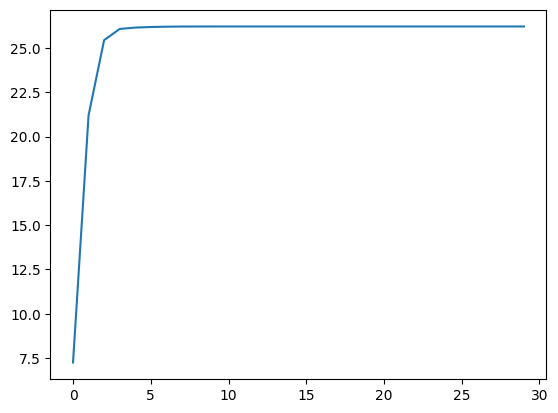

In [ ]:
# 훈련과 테스트 데이터의 정확도 그래프
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

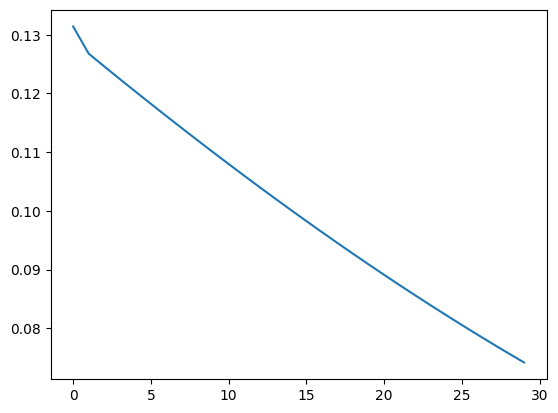

In [ ]:
# 훈련 데이터의 오차 그래프
plt.plot(train_loss_hist)
plt.show()

모델 결과 출력

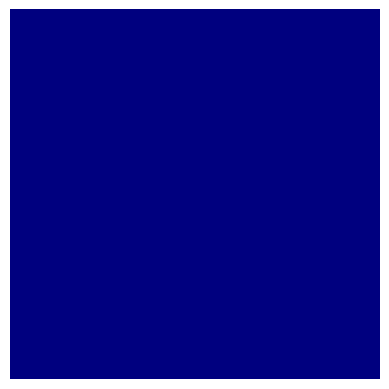

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# 이미지 전처리를 위한 변환 정의
transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])

# 입력 이미지 불러오기
input_image_path = '/content/gdrive/MyDrive/위성데이터/Data/Training/Image/LC_JJ_SN_33606_001_20190503_FGT.jpg'
input_image = Image.open(input_image_path).convert("RGB")
input_tensor = transform(input_image).unsqueeze(0)  # 배치 차원 추가

# 모델 정의 및 가중치 불러오기
model = DeepLabV3()
model.load_state_dict(torch.load('/content/gdrive/MyDrive/위성데이터/model_epoch_28.pth'))
model.eval()

# GPU 사용 가능한 경우 GPU로 이동
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
input_tensor = input_tensor.to(device)

# 입력 이미지에 대한 출력 생성
with torch.no_grad():
    output_tensor = model(input_tensor)

# 출력 텐서를 이미지로 변환
output_image = output_tensor.argmax(1).squeeze().cpu().numpy()
output_image = np.array(output_image, dtype=np.uint8)

# 결과 이미지 시각화
plt.imshow(output_image, cmap='jet')  # 예시로 'jet' colormap 사용
plt.axis('off')
plt.show()
